In [ ]:
!pip install scikit-fuzzy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
print(fuzz.__version__)

0.5.0


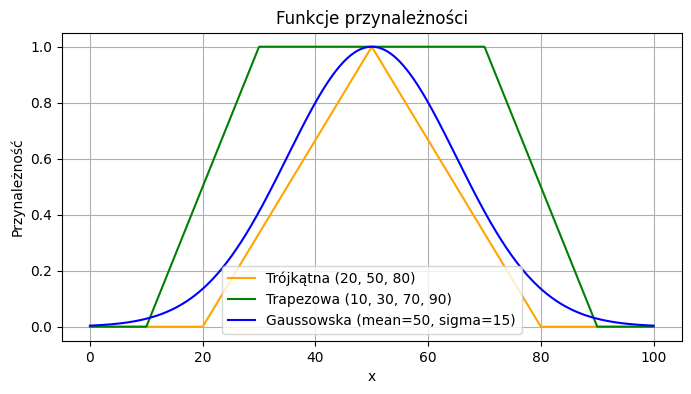

In [ ]:
# uniwersum
x = np.linspace(0, 100, 1000)

# funkcje przynależności
trimf = fuzz.trimf(x, [20, 50, 80])
trapmf = fuzz.trapmf(x, [10, 30, 70, 90])
gaussmf = fuzz.gaussmf(x, mean=50, sigma=15)

plt.figure(figsize=(8,4))
plt.plot(x, trimf, label="Trójkątna (20, 50, 80)", color="orange")
plt.plot(x, trapmf, label="Trapezowa (10, 30, 70, 90)", color="green")
plt.plot(x, gaussmf, label="Gaussowska (mean=50, sigma=15)", color="blue")

plt.title("Funkcje przynależności")
plt.xlabel('x')
plt.ylabel("Przynależność")
plt.grid(True)
plt.legend()
plt.show()

ZADANIE PROJKETOWE

```
Przypomnienie - założenia zadania:
Wejściowe zmienne rozmyte:
  ● Życie gracza (niskie, średnie, wysokie)
  ● Odległość w blokach (mała, duża)


Wyjściowe zmienne rozmyte:
  ● Atak (brak, ostrożny, zdecydowany)  


Reguły aktywacji (Jakie określenia aktywują jaki poziom ataku):
  ● Reguła 1 (życie niskie → zdecydowany atak)
  ● Reguła 2 (życie średnie i odległość duża → średni atak)
  ● Reguła 3 (życie średnie i odległość mała → średni atak)
  ● Reguła 4 (życie wysokie i odległość mała → brak ataku)


Życie gracza
  ● Niskie (funkcja trójkątna [0,0,40])
  ● Średnie (funkcja trójkątna [30,50,70])
  ● Wysokie(funkcja trójkątna [60,100,100])


Odległość
  ● Blisko (funkcja trójkątna [0,0,15])
  ● Daleko (funkcja trójkątna [10,50,50])


Poziom ataku:
  ● Brak ataku (funkcja trójkątna [0,0,30])
  ● Ostrożny atak  (funkcja trójkątna [50,70,90])
  ● Zdecydowany atak  (funkcja trójkątna [80,100,100])
```

Poziom ataku: 73.978929397203


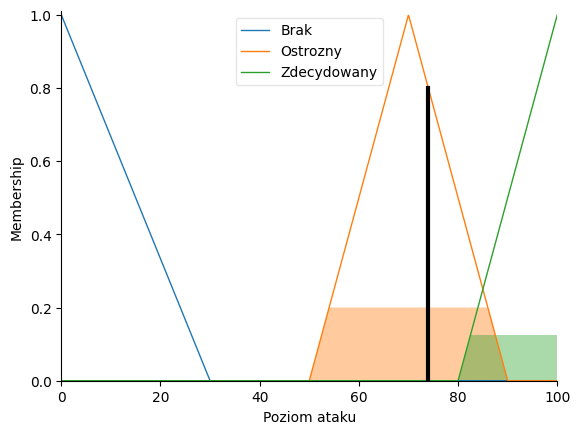

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


# 1. DANE WEJŚCIOWE/WYJŚCIOWE
life = ctrl.Antecedent(np.linspace(0, 100, 1000), 'Zycie gracza')
distance = ctrl.Antecedent(np.linspace(0, 50, 1000), 'Odleglosc')

attack = ctrl.Consequent(np.linspace(0, 100, 1000), 'Poziom ataku')


# 2. FUZYFIKACJA - FUNKCJE PRZYNALEŻNOŚCI
# Życie
life['Niskie'] = fuzz.trimf(life.universe, [0, 0, 40])
life['Srednie'] = fuzz.trimf(life.universe, [30, 50, 70])
life['Wysokie'] = fuzz.trimf(life.universe, [60, 100, 100])

# Odległość
distance['Blisko'] = fuzz.trimf(distance.universe, [0, 0, 15])
distance['Daleko'] = fuzz.trimf(distance.universe, [10, 50, 50])

# Atak
attack['Brak'] = fuzz.trimf(attack.universe, [0, 0, 30])
attack['Ostrozny'] = fuzz.trimf(attack.universe, [50, 70, 90])
attack['Zdecydowany'] = fuzz.trimf(attack.universe, [80, 100, 100])



# 3. REGUŁY
rule1 = ctrl.Rule(life['Niskie'], attack['Zdecydowany'])
rule2 = ctrl.Rule(life['Srednie'] & distance['Daleko'], attack['Ostrozny'])
rule3 = ctrl.Rule(life['Srednie'] & distance['Blisko'], attack['Ostrozny'])
rule4 = ctrl.Rule(life['Wysokie'] & distance['Blisko'], attack['Brak'])


# 4. BUDOWA SYSTEMU
attack_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])


attack_sim = ctrl.ControlSystemSimulation(attack_ctrl)


attack_sim.input['Zycie gracza'] = 35
attack_sim.input['Odleglosc'] = 12

attack_sim.compute()

print(f"Poziom ataku: {attack_sim.output['Poziom ataku']}")
attack.view(sim=attack_sim)